# 24RB1003 松澤颯斗

# 課題１

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 2次元データの生成
s = np.random.rand(100, 1) * 2 * np.pi  # 0から2πの範囲でランダムな値を生成
Z = np.hstack([2*np.cos(s), 3*np.sin(s)])  # 楕円状のデータを生成

# 5次元空間へリフト
P = np.random.randn(2, 5)
X = Z @ P  # 2次元データを5次元空間にリフト

X

array([[ 0.67912827,  0.92622272, -1.42484667,  0.11205716, -2.51176575],
       [-0.07346956, -0.78156022,  1.0782619 ,  0.08580224,  1.93129593],
       [ 2.90803554,  1.2647229 , -2.43737243,  0.86807099, -4.17575203],
       [ 1.32927003,  1.06043197, -1.76829866,  0.32747783, -3.08352927],
       [-0.25862163,  0.69457973, -0.87783543, -0.19319043, -1.59435893],
       [ 3.68537739,  1.22311942, -2.57395483,  1.15468022, -4.36720305],
       [ 2.40248895,  0.01288768, -0.61400093,  0.86547591, -0.93628024],
       [ 3.93649834,  0.94989472, -2.26573534,  1.28460577, -3.79630139],
       [ 2.12941702, -0.09437538, -0.40071956,  0.7823094 , -0.57217098],
       [ 3.86345713,  0.83549354, -2.09243889,  1.2746787 , -3.49014698],
       [-3.28190942, -1.26922039,  2.53630264, -1.00239769,  4.32752489],
       [ 2.27655226,  1.2093159 , -2.20543167,  0.64806082, -3.80295254],
       [ 2.58149528,  1.24179771, -2.32520158,  0.75348073, -3.9969234 ],
       [-1.47971062,  0.32638408, -0.0

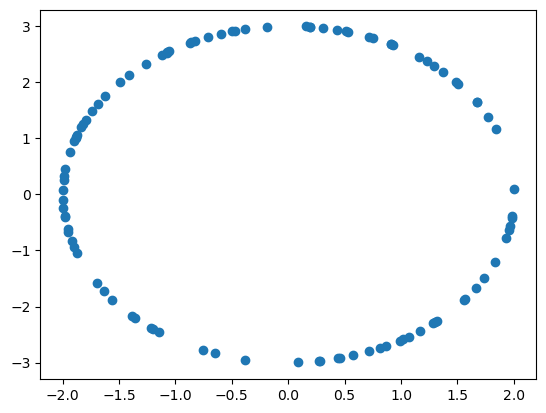

In [3]:
plt.scatter(Z[:, 0], Z[:, 1])

1. 中心化して $M = \frac{1}{m}X^{\top}X$ を計算

In [4]:
# 中心化する
X_centered = X - np.mean(X, axis=0)

# 共分散行列の計算
M = (X_centered.T @ X_centered) / X_centered.shape[0]

M

array([[ 7.66067167,  2.09585222, -4.74466923,  2.4643815 , -7.99017572],
       [ 2.09585222,  0.85860764, -1.68490406,  0.63322959, -2.88068236],
       [-4.74466923, -1.68490406,  3.46328221, -1.47073005,  5.8909377 ],
       [ 2.4643815 ,  0.63322959, -1.47073005,  0.79866449, -2.47054092],
       [-7.99017572, -2.88068236,  5.8909377 , -2.47054092, 10.02587073]])

2. `np.linalg.eigh`で固有値分解

In [5]:
# 固有値分解
eigenvalues, eigenvectors = np.linalg.eigh(M)

eigenvalues, eigenvectors

(array([-5.34579711e-15, -4.51654441e-16,  5.42856871e-16,  1.03174452e+00,
         2.17753522e+01]),
 array([[ 0.07010886, -0.09772383, -0.36115558, -0.7268629 , -0.57163955],
        [ 0.64499889, -0.67379158, -0.0162152 ,  0.30786183, -0.18692112],
        [-0.5214111 , -0.71580117, -0.0563219 , -0.2370739 ,  0.39545285],
        [ 0.02485884, -0.08890336,  0.93017239, -0.3066523 , -0.17950466],
        [ 0.55369097,  0.12719999, -0.03018088, -0.47607956,  0.6705847 ]]))

3. 上位2固有ベクトルで射影し2D散布図をプロット

In [6]:
# 上位2固有ベクトルを取得
V = eigenvectors[:, [-1, -2]]  # 固有値の大きい順に上位2つの固有ベクトルを選択
V

array([[-0.57163955, -0.7268629 ],
       [-0.18692112,  0.30786183],
       [ 0.39545285, -0.2370739 ],
       [-0.17950466, -0.3066523 ],
       [ 0.6705847 , -0.47607956]])

In [7]:
# データを上位2次元の空間に射影
X_pca = X_centered @ V  
X_pca

array([[-2.21530787e+00,  1.18079527e+00],
       [ 2.50815101e+00, -1.49855189e+00],
       [-5.20467019e+00,  4.65296453e-01],
       [-3.16994511e+00,  1.03711843e+00],
       [-7.49644474e-01,  1.31826100e+00],
       [-5.87509668e+00, -7.68959583e-02],
       [-1.78782182e+00, -1.52635708e+00],
       [-5.48617393e+00, -7.28249297e-01],
       [-1.26823576e+00, -1.55929864e+00],
       [-5.14742169e+00, -8.94171867e-01],
       [ 6.81217391e+00, -4.69347964e-01],
       [-4.45212452e+00,  7.42237838e-01],
       [-4.82887415e+00,  6.18998599e-01],
       [ 1.31400878e+00,  1.37524998e+00],
       [-2.38219482e+00, -1.47415818e+00],
       [-5.12539451e+00,  5.01182511e-01],
       [-2.85322466e+00,  1.09042320e+00],
       [-1.66930037e+00,  1.24250262e+00],
       [-5.68402283e+00,  1.70882639e-01],
       [-1.02231096e+00,  1.29925727e+00],
       [-5.52112786e+00,  2.92527805e-01],
       [-2.38216813e+00, -1.47416090e+00],
       [-5.45724177e+00, -7.44984631e-01],
       [-2.

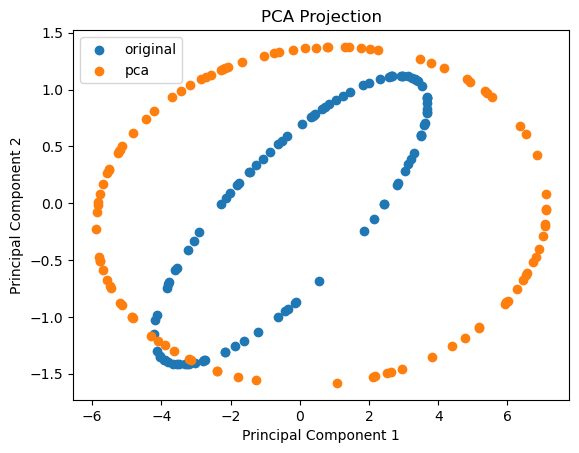

In [8]:
# 射影されたデータをプロット
plt.scatter(X_centered[:, 0], X_centered[:, 1], label='original')
plt.scatter(X_pca[:, 0], X_pca[:, 1], label='pca')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.legend()
plt.show()


# 課題２

In [9]:
from sklearn.decomposition import PCA

In [10]:
X_skpca = PCA(n_components=2).fit_transform(X)
X_skpca

array([[-2.21530787e+00, -1.18079527e+00],
       [ 2.50815101e+00,  1.49855189e+00],
       [-5.20467019e+00, -4.65296453e-01],
       [-3.16994511e+00, -1.03711843e+00],
       [-7.49644474e-01, -1.31826100e+00],
       [-5.87509668e+00,  7.68959583e-02],
       [-1.78782182e+00,  1.52635708e+00],
       [-5.48617393e+00,  7.28249297e-01],
       [-1.26823576e+00,  1.55929864e+00],
       [-5.14742169e+00,  8.94171867e-01],
       [ 6.81217391e+00,  4.69347964e-01],
       [-4.45212452e+00, -7.42237838e-01],
       [-4.82887415e+00, -6.18998599e-01],
       [ 1.31400878e+00, -1.37524998e+00],
       [-2.38219482e+00,  1.47415818e+00],
       [-5.12539451e+00, -5.01182511e-01],
       [-2.85322466e+00, -1.09042320e+00],
       [-1.66930037e+00, -1.24250262e+00],
       [-5.68402283e+00, -1.70882639e-01],
       [-1.02231096e+00, -1.29925727e+00],
       [-5.52112786e+00, -2.92527805e-01],
       [-2.38216813e+00,  1.47416090e+00],
       [-5.45724177e+00,  7.44984631e-01],
       [-2.

In [11]:
# X_pca と X_skpca が一致している確認
np.allclose(np.abs(X_pca), np.abs(X_skpca)) # PCAは符号が不定なので、絶対値で比較

True

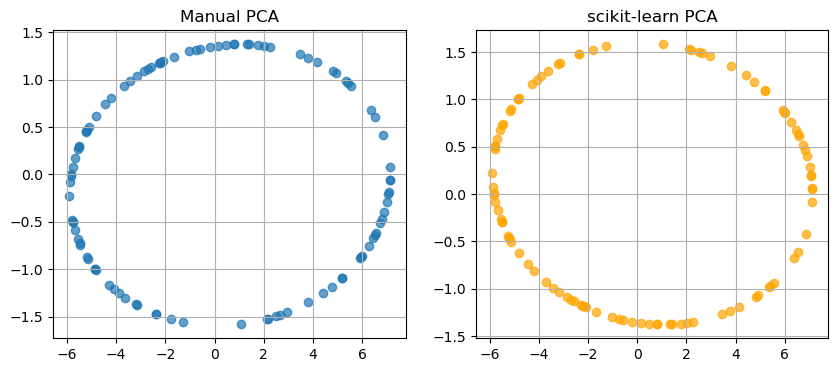

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 課題１のPCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
axes[0].set_title('Manual PCA')
axes[0].grid(True)

# scikit-learnのPCA
axes[1].scatter(X_skpca[:, 0], X_skpca[:, 1], alpha=0.7, color='orange')
axes[1].set_title('scikit-learn PCA')
axes[1].grid(True)

plt.show()

In [25]:
print("課題1のPCA:\n", X_pca[:10])
print("\nscikit-learnのPCA:\n", X_skpca[:10])

課題1のPCA:
 [[-2.21530787  1.18079527]
 [ 2.50815101 -1.49855189]
 [-5.20467019  0.46529645]
 [-3.16994511  1.03711843]
 [-0.74964447  1.318261  ]
 [-5.87509668 -0.07689596]
 [-1.78782182 -1.52635708]
 [-5.48617393 -0.7282493 ]
 [-1.26823576 -1.55929864]
 [-5.14742169 -0.89417187]]

scikit-learnのPCA:
 [[-2.21530787 -1.18079527]
 [ 2.50815101  1.49855189]
 [-5.20467019 -0.46529645]
 [-3.16994511 -1.03711843]
 [-0.74964447 -1.318261  ]
 [-5.87509668  0.07689596]
 [-1.78782182  1.52635708]
 [-5.48617393  0.7282493 ]
 [-1.26823576  1.55929864]
 [-5.14742169  0.89417187]]


# 課題３

In [13]:
import sklearn

iris = sklearn.datasets.load_iris() # irisデータセットの読み込み
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [14]:
iris.data.shape, iris.target.shape

((150, 4), (150,))

In [15]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [16]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [17]:
# PCAで2次元に射影
iris_pca = PCA(n_components=2).fit_transform(iris.data)
iris_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

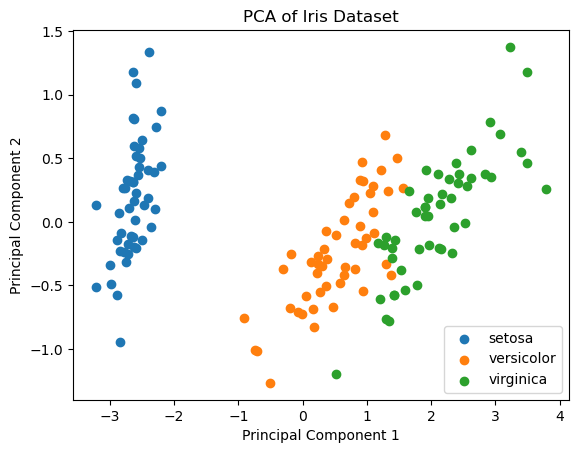

In [18]:
# クラスごとに色分けしてプロット
for target in np.unique(iris.target):
    plt.scatter(iris_pca[iris.target == target, 0], iris_pca[iris.target == target, 1], label=iris.target_names[target])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()

$
\text{寄与率} = \frac{\lambda_i}{\sum_{j}\lambda_j}
$
  
全体の情報のうち主成分が何割を説明しているか

In [19]:
# 寄与率を計算
pca = PCA(n_components=2).fit(iris.data) 
explained_variance_ratio = pca.explained_variance_ratio_ 
explained_variance_ratio # 寄与率

array([0.92461872, 0.05306648])

In [20]:
# どの程度の情報を保持できるか
total_explained_variance = np.sum(explained_variance_ratio)
total_explained_variance

np.float64(0.9776852063187977)

上記のコードより上位2成分で約97.8%の情報を保持できることが確認できた．

# 考察  
PCAがデータの分散を最大化する手法であることを実装を通して理解した．scikit-learnとの比較では，固有ベクトルの符号の任意性により第2主成分の符号が反転したのだと考えられる．また，irisデータの分析では，元の4次元データを2次元に射影しても寄与率が約97.8%に達し，ほとんどの情報を保持できていることが確認できた．散布図でもクラスごとに分離されており，次元削減の有用性を理解した．

# AI使用について  
Gemini Guided Learningを使用して，PCAや共分散行列や固有値分解に加え，scikit-learnでの実装方法やIrisデータセットのデータの抽出やラベルを用いたプロットについて質問した．AIに直接コードを生成させることはせず，実装の方針や考え方のヒントのみをもらい，それをもとに自身でコードを作成した．なお，プロットなどの実際のコーディング作業においては，GitHub Copilotの自動補完を補助的に活用してコードを生成した．